# 5. The transfer-matrix spectrum: block power method, the entanglement barrier, and the wall

The transverse contraction stops converging beyond a certain time. This notebook investigates why by looking directly at the spectrum of the spatial transfer matrix $\mathcal{E}$.

Some of the findings are:
1. Single-vector deflation (running the PM in the subspace orthogonal to the direction of the dominant eigenvector) for the subleading eigenvalue fails (NaNs/Infs at the degeneracy), so we use a block power method (validated against exact diagonalization).
2. The gap closes. The two leading eigenvalues approach each other while $|\lambda_0|$ stays flat (which can be thought as a manifestation of the entanglement barrier, but in the transfer spectrum). The gap closes faster for the NNN model, and the leading eigenvalue traced in the complex plane lies on a circle (emergent dual unitarity).
3. The temporal entropy breaks at the gap closing (end of the
   reach of the method). This NB investigates this closing gap phenomenom.
4. Appendix: we show why our quench to the critical point is not a DQPT.

> **Note (UV regulator):** All spectral data computed here comes from the converged **$n_\beta=4$** master block-PM which uses the $\beta_0=0.2$ cooling required for a clean conformal boundary state.
> Without the UV regulator, there is no conformal boundary.

In [1]:
include("../src/thesislib.jl")
using JLD2, LsqFit, Printf, Plots
gr()

# Load the cached block-power-method results from notebook 7.
cachefile = "../results/data/nb8_master.jld2"
isfile(cachefile) || error("Missing $(cachefile). Run notebook 7 first.")
d = load(cachefile, "done")

# Helper functions for reading the cache
function has_theta_entry(p, T)
    return haskey(d, (p, T)) && haskey(d[(p, T)], :theta)
end

function times_for_parameter(p)
    candidate_times = [T for ((p_value, T), _) in d if p_value == p && has_theta_entry(p, T)]
    return sort(candidate_times)
end

# Helpers for handling phases of complex eigenvalues
function phase_of(z)
    return angle(-z)
end

function unwrap_phases(phases)
    unwrapped = copy(phases)
    for i in 2:length(unwrapped)
        while unwrapped[i] - unwrapped[i-1] > π
            unwrapped[i] -= 2π
        end
        while unwrapped[i] - unwrapped[i-1] < -π
            unwrapped[i] += 2π
        end
    end
    return unwrapped
end

function phase_difference(a, b)
    return mod(phase_of(a) - phase_of(b) + π, 2π) - π
end

# Track the physical leading eigenvalue λ0 by following the eigenvalue whose
# modulus changes most smoothly from one temperature to the next.
function track_lambda0(p)
    lambda_values = ComplexF64[]
    previous_modulus = nothing

    for T in times_for_parameter(p)
        theta_values = d[(p, T)].theta

        if previous_modulus === nothing
            idx = 1
        else
            idx = argmin(abs.(abs.(theta_values) .- previous_modulus))
        end

        current_value = theta_values[idx]
        push!(lambda_values, current_value)
        previous_modulus = abs(current_value)
    end

    return times_for_parameter(p), lambda_values
end

println("Loaded master sweep: p=0 → ", length(times_for_parameter(0.0)),
        " points, p=0.1 → ", length(times_for_parameter(0.1)),
        " points (T=2..12, nbeta=4)")

Loaded master sweep: p=0 → 11

 points, p=0.1 → 11 points (T=2..12, nbeta=4)


## Why we need the block PM

The power method converges at a rate set by the gap ratio $|\lambda_1|/ \lambda_0|$ between the two leading transfer-matrix eigenvalues: as it approaches $1$, the PM finds it harder to converge to a well-defined vector.

One way to measure $\lambda_1$ is by deflation: iterate in the subspace orthogonal to the dominant pair $(\langle L_0|,|R_0\rangle)$, projecting it out at every step with the bilinear (non-conjugating) overlap. But deflation divides by the dominant eigenvalue and relies on the bi-orthogonal pair staying well separated. Precisely at the gap closing (where $|\lambda_1|\to|\lambda_0|$), the residual after projection collapses to (near) zero norm, so normalizing it produces `NaN`/`Inf`, which crashes the simulation. 

Another solution is to use the block power method (`block_transfer_eigs`): an oblique Rayleigh-Ritz (Petrov-Galerkin) subspace iteration that extracts the leading $k$ eigenvalues at once and never divides by a single dominant one. For details on how it works, read the corresponding NB. 

## Validating the block PM against exact ground truth

We must check whether the block PM returns the right leading
eigenvalues. For a handful of time steps, the rotated transfer operator is small enough to contract into a dense matrix and diagonalize exactly with `eigen`. We then can test the block PM results with the exact spectrum (ground truth).

We run this on all models (Alcaraz VD2 and WII, Ising Murg).

In [2]:
using LinearAlgebra, Random, Logging

# Contract an MPO into a plain dense matrix so we can diagonalize it exactly
# (rows are the primed (output) legs, columns the unprimed (input) legs)
function dense_mpo_matrix(mpo::MPO)
    contracted = mpo[1]
    for i in 2:length(mpo)
        contracted = contracted * mpo[i]
    end
    unprimed_indices = [noprime(s) for s in inds(contracted) if plev(s) == 0]
    column_combiner  = combiner(unprimed_indices...)
    row_combiner     = combiner(prime.(unprimed_indices)...)
    dense            = row_combiner * contracted * column_combiner
    return Matrix(dense, combinedind(row_combiner), combinedind(column_combiner))
end

validation_cases = [
    ("Alcaraz VD2  p=0.1",  AlcarazParams(lambda=1.0, p=0.1), AlcarazVD2(), 0.3, 0),
    ("Alcaraz WII  p=0.1",  AlcarazParams(lambda=1.0, p=0.1), AlcarazWII(), 0.3, 0),
    ("Ising Murg   crit",   IsingParams(1.0, 1.0, 0.0),       Murg(),       0.4, 4),
]

# Disable unnecessary warnings
ITensors.disable_warn_order()
Logging.disable_logging(Logging.Warn)

for (label, model_params, scheme, T, nbeta) in validation_cases
    mpo, scaffold = build_tmpo(model_params, scheme, T; dt=0.1, nbeta=nbeta)

    dense_dimension = prod(dim.(siteinds(scaffold)))
    if dense_dimension > 2500
        println(label, ":  dense size $dense_dimension too big, skipped")
        continue
    end

    # exact spectrum from dense diagonalization (the ground truth)
    dense_matrix   = dense_mpo_matrix(mpo)
    exact_spectrum = sort(eigvals(dense_matrix), by=abs, rev=true)
    dense_matrix   = nothing
    GC.gc()

    # the block power method, on the same tMPO
    Random.seed!(11)
    theta, _, _, info = block_transfer_eigs(mpo, scaffold; k=4, maxdim=256, cutoff=1e-14,
                                            itermax=2000, eps_conv=1e-10)

    leading_error = maximum(abs.(sort(theta, by=abs, rev=true)[1:2] .- exact_spectrum[1:2]))
    exact_moduli  = join([@sprintf("%.4f", abs(x)) for x in exact_spectrum[1:4]], " ")
    @printf("%-20s  n=%-5d  exact |λ|=[%s]  block err(top2)=%.1e  (%s@%d)\n",
            label, dense_dimension, exact_moduli, leading_error, info[:reason], info[:niters])

    # the ± pair sits ≈π apart in phase only at large T; at these tiny T it is NOT yet π
    pair_phase_gap = abs(angle(exact_spectrum[1]) - angle(exact_spectrum[2])) / pi
    @printf("%-20s  arg(λ1) − arg(λ2) = %.3f π  (the ± structure, still emerging at small T)\n", "", pair_phase_gap)
    GC.gc()
end

Logging.disable_logging(Logging.BelowMinLevel)   # restore normal logging for later cells


Alcaraz VD2  p=0.1    n=343    exact |λ|=[0.9598 0.3263 0.0882 0.0550]  block err(top2)=1.4e-08  (converged@8)
                      arg(λ1) − arg(λ2) = 0.665 π  (the ± structure, still emerging at small T)


Alcaraz WII  p=0.1    n=27     exact |λ|=[0.9758 0.3292 0.0918 0.0524]  block err(top2)=4.6e-13  (converged@8)
                      arg(λ1) − arg(λ2) = 0.670 π  (the ± structure, still emerging at small T)


Ising Murg   crit     n=256    exact |λ|=[1.5488 0.0611 0.0230 0.0211]  block err(top2)=4.2e-10  (converged@13)
                      arg(λ1) − arg(λ2) = 0.612 π  (the ± structure, still emerging at small T)


LogLevel(-1000000)

The block method reproduces the exact spectrum on every model tested: Alcaraz VD2 to $\sim10^{-8}$, Alcaraz WII and Ising Murg to $\sim10^{-10}$–$10^{-13}$.

**Why is the top pair $0.6$–$0.7\pi$ apart, and not $\pi$?** Because these validation runs use deliberately short times ($T=0.3$–$0.4$) which are small enough that the dense transfer matrix stays $\le2500$-dimensional and can be diagonalized exactly. 

At such short $T$, the spectrum still has a large gap: the subdominant eigenvalues sit far below $\lambda_0$ (e.g. Ising, $|\lambda|=[1.55,\,0.06,\,0.02,\dots]$), so there is no near-degeneracy yet; this is exactly why the block method is easy to validate here. The $\approx0.6-0.7\pi$ figure is just the phase separation of two deeply subdominant states, not a near-degenerate $\pm$ pair.

The $\pm\pi$ near-degeneracy that dominates the rest of this NB ($\lambda_0$ and its odd-parity partner at nearly equal modulus, $\approx\pi$ apart in phase) is a large-$T$ feature. As $T$ grows, the displaced odd tower rises to nearly full modulus and its phase separation tightens toward $\pi$: the displacement is $\pi - \pi x/(vT)$, i.e. exact only as $T\to\infty$ (the finite-$T$ CFT correction $\pi x/(vT)$ is what holds it below $\pi$; see NB7/`pairing_partners.ipynb`). 

So the partner eigenvalues are genuine, exact eigenvalues at every $T$; it is only their $\pi$-displacement and their near-degeneracy with $\lambda_0$ that emerge with $T$, and at these short validation times neither has developed.

## The gap closes

With the block PM, we can trace the leading eigenvalues cleanly through the degeneracy.

The transfer-matrix spectrum splits into two towers. Besides $\lambda_0$ and its own CFT descendants (all at *small* phase relative to $\lambda_0$), there is a second family sitting $\approx\pi$ away in phase, at nearly equal modulus. It is not a numerical artifact, but a *real* CFT state: the odd-parity boundary tower displaced by momentum $\approx\pi$. This is a genuine property of the interacting (NNN) model; the free-fermion Ising chain has no such partner. NB7 and `pairing_partners.ipynb` identify it explicitly (reading $x=1/2,3/2,\ldots$ off the $\pi$ side) and explain the mechanism (the NNN coupling is a fermion interaction that attaches a momentum-$\pi$ phase to the odd sector).

The naive ratio of the two largest moduli $|\theta_2|/|\theta_1|$ measures the near-degeneracy between $\lambda_0$ and its $\pi$-displaced partner (dotted line below), not the gap to the next state in $\lambda_0$'s own tower. Taken naively, the $p=0.1$ gap looks almost closed by $T\approx5-6$ ($|\theta_2|/|\theta_1|\approx0.999$), but that is only the partner's modulus approaching $|\lambda_0|$, not $\lambda_0$ losing its physical gap. (*Note: the non-monotonic wiggle of the naive curve is exactly this partner's modulus crossing and re-crossing $|\lambda_0|$*)

The physical gap divides $\lambda_0$ by the next member of its *own* tower: every eigenvalue within $\pi/2$ in phase of $\lambda_0$ is a descendant; the $\approx\pi$ partner is excluded. This gap (solid line) is well-behaved: it starts well away from $1$ and closes monotonically with $T$, which can be thought as a manifestation of the entanglement barrier, present for both $p=0$ and $p=0.1$. 

A clean cross-$p$ comparison of the barrier is subtle, because the tower's very membership changes with $p$: at $p=0$ the low odd states $x=1/2,3/2$ sit inside the tower, while at $p\neq0$ they leave for the partner tower, so the leading tower descendant jumps from $x=1/2$ up to $x=2$. The anatomy cell below quantifies this.

**IMPORTANT NOTE:** The data we plot and study here is from the master block PM sweep performed in NB7. Check the first cells to see how the data was generated.

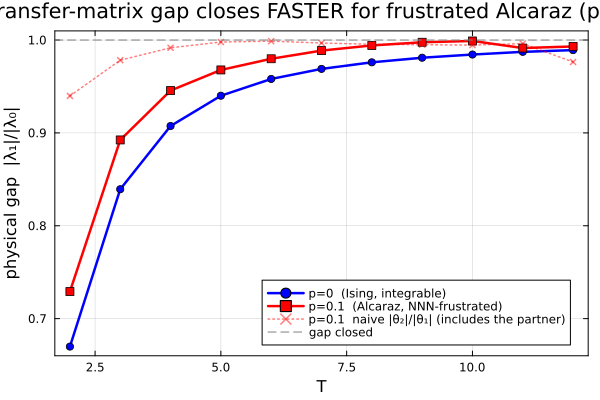

In [3]:
# Compute the gap ratio |λ₁|/|λ₀|
function compute_gap_ratio(p; use_physical_gap=true)
    times = times_for_parameter(p)
    ratios = Float64[]

    for T in times
        entry = d[(p, T)]
        theta_values = entry.theta

        if use_physical_gap
            physical_index = haskey(entry, :i0) ? entry.i0 : 1
            partner_index = haskey(entry, :ip) ? entry.ip : 2

            other_indices = [j for j in eachindex(theta_values) if j != physical_index && j != partner_index]
            lambda0_modulus = abs(theta_values[physical_index])
            lambda1_modulus = isempty(other_indices) ? 0.0 : maximum(abs(theta_values[j]) for j in other_indices)
        else
            lambda0_modulus = abs(theta_values[1])
            lambda1_modulus = abs(theta_values[2])
        end

        if lambda0_modulus < 1e-30
            push!(ratios, 0.0)
        else
            push!(ratios, lambda1_modulus / lambda0_modulus)
        end
    end

    return times, ratios
end

# Compute physical gap for the two parameter values
times_ising, gap_ising = compute_gap_ratio(0.0)
times_alcaraz, gap_alcaraz = compute_gap_ratio(0.1)

# Compute naive ratio for p = 0.1
_, naive_alcaraz = compute_gap_ratio(0.1; use_physical_gap=false)

pltg = plot(
    times_ising, gap_ising;
    label="p=0  (Ising, integrable)",
    marker=:circle, lw=2.5, color=:blue,
    xlabel="T", ylabel="physical gap  |λ₁|/|λ₀|",
    framestyle=:box, grid=true, legend=:bottomright,
    title="Transfer-matrix gap closes FASTER for frustrated Alcaraz (p=0.1)"
)

plot!(pltg, times_alcaraz, gap_alcaraz;
    label="p=0.1  (Alcaraz, NNN-frustrated)",
    marker=:square, lw=2.5, color=:red
)

plot!(pltg, times_alcaraz, naive_alcaraz;
    label="p=0.1  naive |θ₂|/|θ₁| (includes the partner)",
    ls=:dot, lw=1.5, color=:red, alpha=0.5, marker=:x, ms=3
)

hline!(pltg, [1.0]; ls=:dash, color=:gray, label="gap closed")

mkpath("../results/imgs")
savefig(pltg, "../results/imgs/block_pm_ising_vs_alcaraz.png")

pltg

### Extending the picture to $p=0.3$ and $p=0.5$

The gap plot above uses the physical/partner indices `i0`/`ip` cached by notebook 7's `pick_phys` selector, which, like `compute_gap_ratio`'s `use_physical_gap=true` branch, only ever compares the two *largest-modulus* eigenvalues. 

In NB3 we found that this selector breaks down once frustration grows: extra $\pm\lambda_0$-type partners crowd into the leading block, and a rank-based choice (index 1 vs 2) can grab a partner instead of the genuine $\lambda_1$. At $p=0.3$, $T=4$ the entire $k=4$ block turns out to be $\lambda_0$ plus three partners, with $\lambda_1$ missing altogether (recovering it needs $k=6$).

The fix (NB3) is to classify each eigenvalue by its *phase* relative to $\lambda_0$ instead of by modulus rank: the "tower" is every eigenvalue within $\pi/2$ of $\lambda_0$'s phase, the "partners" are the rest. We reuse that classifier here (built from the same `phase_of`/`phase_difference` helpers already defined above) applied to notebook 3's $p$-sweep cache, to check whether "the gap closes faster for larger $p$" survives once $p=0.3$ and $p=0.5$ are added with the corrected selector.

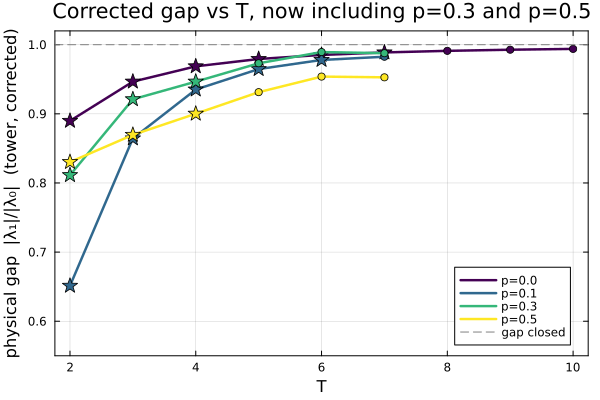

In [4]:
function tower_gap_from_spectrum(theta_values)
    lambda0_index = argmax(abs.(theta_values))

    tower_descendant_moduli = Float64[]
    for j in eachindex(theta_values)
        j == lambda0_index && continue
        phase_gap = phase_difference(theta_values[j], theta_values[lambda0_index])
        if abs(phase_gap) < pi / 2
            push!(tower_descendant_moduli, abs(theta_values[j]))
        end
    end

    if isempty(tower_descendant_moduli)
        return NaN   # λ1 was not captured in this block at all (would need a bigger k)
    end
    return maximum(tower_descendant_moduli) / abs(theta_values[lambda0_index])
end

# Load the p=0.3 / p=0.5 sweep computed in notebook 3 (k=4, T=2..7 + k=6 cross-checks)
p_sweep_cache = "../results/data/nb55_pgap.jld2"
k6_cache      = "../results/data/nb3_gap_k6.jld2"
isfile(p_sweep_cache) || error("Missing $(p_sweep_cache). Run notebook 3 first.")
isfile(k6_cache) || error("Missing $(k6_cache). Run notebook 3 first.")
p_gap_from_nb3 = load(p_sweep_cache, "D")
k6_from_nb3    = load(k6_cache, "done")

extended_p_values = [0.0, 0.1, 0.3, 0.5]
extended_colors   = cgrad(:viridis, length(extended_p_values), categorical=true)

extended_gap_plot = plot(
    xlabel="T", ylabel="physical gap  |λ₁|/|λ₀|  (tower, corrected)",
    framestyle=:box, grid=true, legend=:bottomright, ylims=(0.55, 1.02),
    title="Corrected gap vs T, now including p=0.3 and p=0.5"
)

for (i, p) in enumerate(extended_p_values)
    T_sorted = sort(collect(keys(p_gap_from_nb3[p])))

    gap_values   = Float64[]
    came_from_k6 = Bool[]
    for T in T_sorted
        k6_key = (:k6, p, T)
        if haskey(k6_from_nb3, k6_key)
            push!(gap_values, tower_gap_from_spectrum(k6_from_nb3[k6_key].theta))
            push!(came_from_k6, true)
        else
            push!(gap_values, tower_gap_from_spectrum(p_gap_from_nb3[p][T].theta))
            push!(came_from_k6, false)
        end
    end

    plot!(extended_gap_plot, T_sorted, gap_values; color=extended_colors[i], lw=2.5, label="p=$p")

    k6_positions = findall(came_from_k6)
    scatter!(extended_gap_plot, T_sorted[k6_positions], gap_values[k6_positions];
             color=extended_colors[i], marker=:star5, ms=8, label="")

    k4_positions = findall(.!came_from_k6)
    scatter!(extended_gap_plot, T_sorted[k4_positions], gap_values[k4_positions];
             color=extended_colors[i], marker=:circle, ms=4, label="")
end
hline!(extended_gap_plot, [1.0]; ls=:dash, color=:gray, label="gap closed")

mkpath("../results/imgs")
savefig(extended_gap_plot, "../results/imgs/gap_vs_p_extended.png")
extended_gap_plot

The corrected picture is not monotonic in $p$ (as we expected). Restricting to $T=2,3,4$, where we have an exact $k=6$ cross-check (star markers; the two block sizes agree to 4 digits, see NB3):

| T | p=0 | p=0.1 | p=0.3 | p=0.5 |
|---|-----|-------|-------|-------|
| 2 | 0.890 | 0.651 | 0.811 | 0.830 |
| 3 | 0.947 | 0.864 | 0.921 | 0.870 |
| 4 | 0.969 | 0.935 | 0.947 | 0.900 |

At every one of these $T$, the unfrustrated $p=0$ Ising line has the largest gap ratio (closest to closed) of all four. This is the opposite ranking from the title of the plot above, which only ever compared $p=0$ against $p=0.1$. The frustrated cases don't even order consistently among themselves: $p=0.5>p=0.3$ at $T=2$, but $p=0.3>p=0.5$ at $T=3,4$.

This is not necessarily a contradiction of "frustration scrambles the state faster". It may instead mean we're comparing the wrong things. NB3 shows that $p=0$'s lowest tower state is the $x=1/2$ boundary operator (Carignano-Tagliacozzo's free-BC result), while $p=0.1$'s (and possibly $p=0.3$'s and $p=0.5$'s) lowest *visible* tower state sits at a different scaling dimension. Comparing $|\lambda_1|/|\lambda_0|$ across $p$ is only a fair "gap closes faster/slower" statement once we've checked we are tracking the *same* $x_n$ on both sides. Otherwise, we are comparing the barrier's approach to two different CFT operators. **Open question.**

### The anatomy of the spectrum: one tower ($p=0$) vs. two ($p\neq0$)

The claim above (that frustration adds a whole tower rather than merely closing a gap) is visible directly in the leading block. At each $p$ (fixed $T=4$), we classify every eigenvalue by its phase relative to $\lambda_0$ (`classify_tower` from the library) and compare the modulus of the nearest tower descendant against the nearest partner. If the hypothesis is right we expect: $p=0$ has no partner (the nearest subdominant state is a genuine tower descendant), while for $p\neq0$ a partner appears at nearly full modulus, closer to $\lambda_0$ than the tower descendant, and closer still as $p$ grows.

In [5]:
# classify_tower (library) splits the block by PHASE relative to λ0:
#   tower   = |Δφ| < π/2  → λ0's own (even-parity) CFT descendants
#   partner = |Δφ| ≳ π/2  → the π-DISPLACED odd-parity tower (only present for the interacting model)
# We read p=0 and p=0.1 from the master sweep, and the tiny-p points from the k=8 odd-scan cache.
using JLD2

oddscan_data = load("../results/data/nb7_oddscan.jld2", "done")     # k=8 blocks, p=0.01..0.15, T=4
measured_v   = load("../results/data/alcaraz_velocity.jld2", "v")   # v(p) from NB4: Dict p => v(p)

# v(p) is only needed to LABEL the leading partner's dimension x

# The odd-scan probes p = 0.01, 0.05, 0.15, which fall between those grid points, so we linearly
# interpolate v(p) between the two nearest MEASURED values
function v_at(p)
    if p <= 0.1
        return measured_v[0.0] + (measured_v[0.1] - measured_v[0.0]) * (p - 0.0) / (0.1 - 0.0)
    else
        return measured_v[0.1] + (measured_v[0.3] - measured_v[0.1]) * (p - 0.1) / (0.3 - 0.1)
    end
end

spectra_at_T4 = Dict{Float64, Vector{ComplexF64}}()
spectra_at_T4[0.0] = d[(0.0, 4.0)].theta
spectra_at_T4[0.1] = d[(0.1, 4.0)].theta
for p in [0.01, 0.05, 0.15]
    spectra_at_T4[p] = collect(oddscan_data[p].theta)
end

@printf("nearest tower descendant vs nearest partner (@ T=4):\n\n")
@printf("  %-6s %-9s %-16s %-16s %-9s %s\n",
        "p", "#partner", "|λ1_tower|/|λ0|", "|λ_partner|/|λ0|", "nearest", "leading partner x≈")

for p in sort(collect(keys(spectra_at_T4)))
    theta   = spectra_at_T4[p]
    i0      = argmax(abs.(theta))
    lambda0 = theta[i0]

    tower_ratios   = Float64[]
    partner_ratios = Float64[]
    partner_dims   = Float64[]
    for j in eachindex(theta)
        j == i0 && continue
        dphi          = phase_difference(theta[j], lambda0)
        modulus_ratio = abs(theta[j]) / abs(lambda0)
        if abs(dphi) < pi/2
            push!(tower_ratios, modulus_ratio)
        else
            push!(partner_ratios, modulus_ratio)
            push!(partner_dims, v_at(p) * 4.0 * (pi - abs(dphi)) / pi)   # x from the π side
        end
    end

    leading_tower   = isempty(tower_ratios)   ? NaN : maximum(tower_ratios)
    leading_partner = isempty(partner_ratios) ? NaN : maximum(partner_ratios)
    nearest_class   = isnan(leading_partner) ? "tower" :
                      (leading_partner > leading_tower ? "PARTNER" : "tower")
    partner_x_str   = isempty(partner_dims) ? "   —" : @sprintf("%.2f", minimum(partner_dims))
    partner_ratio_str = isnan(leading_partner) ? "      —" : @sprintf("%.4f", leading_partner)

    @printf("  %-6.2f %-9d %-16.4f %-16s %-9s %s\n",
            p, length(partner_ratios), leading_tower, partner_ratio_str, nearest_class, partner_x_str)
end


nearest tower descendant vs nearest partner (@ T=4):

  p      #partner  |λ1_tower|/|λ0|  |λ_partner|/|λ0| nearest   leading partner x≈


  0.00   0         0.9687                 —          tower        —
  0.01   4         0.8846           0.9706           PARTNER   0.48


  0.05   4         0.9008           0.9796           PARTNER   0.48
  0.10   2         0.9352           0.9917           PARTNER   0.47
  0.15   4         0.9546           0.9944           PARTNER   0.45


The table confirms the picture precisely:

- $p=0$ has no partner. The block is a single interleaved tower, and the nearest subdominant state is a genuine tower descendant ($|\lambda_1|/|\lambda_0|=0.969$; the $x=1/2$ rung, which at $p=0$ still lives near $\lambda_0$).
- $p\neq0$: a partner tower appears, and its leading member is the nearest-in-modulus state at every $p$ (closer to $\lambda_0$ than the tower descendant) reading $x\approx1/2$ (the displaced odd fermion). Its modulus ratio increases toward $1$ as frustration grows: $0.971\,(p{=}0.01)\to0.980\to0.992\to0.994\,(p{=}0.15)$.

Two consequences:

1. The tower's "membership" changes at $p=0^+$. The leading tower descendant jumps from $x=1/2$ (at $p=0$, ratio $0.969$) to $x=2$ (at $p=0.01$, ratio $0.885$); the $x=1/2$ state didn't vanish, it moved to the partner tower. This is why a raw cross-$p$ comparison of the "tower gap" is not apples-to-apples, and it directly proved that the NNN interaction opens a new, momentum-$\pi$ odd tower, which sits nearer $\lambda_0$ in modulus than anything the free-fermion chain has, and nearer still as $p$ grows.
2. The naive modulus-rank selector is doomed for $p\neq0$. The nearest-modulus subdominant is always the partner, so ranking by $|\theta|$ hands back the partner as "$\lambda_1$" and reports the $\pm$ near-degeneracy instead of the physical gap. Only the phase classification (`tower_gap`) recovers the real gap (by tracking $\lambda_0$ by continuity and classifying by phase, never by modulus rank).

## RTM vs RDM in the block PM

We want to investigate how trustworthy the RTM truncation really is: the SVD of the non-Hermitian transition matrix $|R\rangle\langle L|$ used inside `trunc_mode=:rtm` is ill-conditioned near a degeneracy, so to check whether it spits reliable results or not, `block_transfer_eigs` also offers `trunc_mode=:rdm`: the Hermitian per-vector reduced density matrix $|v\rangle\langle v^*|$ (the block analogue of `powermethod_lr`'s `alg="densitymatrix"`), a positive, well-conditioned eigenproblem built in a completely different way from RTM.

We recompute the same $|\theta_2|/|\theta_1|$ ratio with both truncation modes (same random seed) at $T=6,8,10$ and compare.


In [6]:
# block_transfer_eigs truncates each de-mixed Ritz pair two ways (trunc_mode kwarg):
#   :rtm — bilinear transition matrix |R⟩⟨L|  (block analogue of powermethod_lr alg="RTM");
#          optimal for ⟨L|R⟩ but a NON-Hermitian SVD, ill-conditioned at the degeneracy
#   :rdm — Hermitian per-vector RDM |v⟩⟨v*|    (block analogue of alg="densitymatrix");
#          drops the L–R coupling but a POSITIVE Hermitian eigenproblem → stable
# Set should_regenerate=true to (re)compute missing points (like the missing T=10)
using Random

comparison_file = "../results/data/nb5_rtm_vs_rdm.jld2"
should_regenerate = false  
comparison_data = isfile(comparison_file) ? load(comparison_file, "done") : Dict{Tuple{Float64, Symbol}, Any}()

if should_regenerate
    # We now just want to recompute T=10 RDM run only
    temperatures = [10.0]
    truncation_modes = (:rtm, :rdm)

    for T in temperatures, mode in truncation_modes
        haskey(comparison_data, (T, mode)) && continue

        Random.seed!(20260627)  # use the same seed for both truncation modes at each temperature

        mpo, scaffold = build_alcaraz_tmpo(T; p=0.1, lambda=1.0, dt=0.1, nbeta=4, MPO_alg="VD2")

        theta_values, _, _, info = block_transfer_eigs(
            mpo, scaffold;
            k=4,
            maxdim=64,
            maxdims=collect(2:2:64),
            cutoff=1e-12,
            cutoffs=[fill(1e-8, 40); 1e-10],
            itermax=400,
            eps_conv=1e-6,
            trunc_mode=mode,
            n_track=2,
            stuck_after=200
        )

        comparison_data[(T, mode)] = (
            theta=theta_values,
            gap=abs(theta_values[2]) / abs(theta_values[1]),
            niters=info[:niters],
            reason=info[:reason]
        )

        jldsave(comparison_file; done=comparison_data)
    end
end

available_temperatures = sort(unique(T for (T, _) in keys(comparison_data)))

@printf("%-5s | %-9s %-9s | %-16s %-16s | %s\n",
    "T", "RTM gap", "RDM gap", "RTM reason@it", "RDM reason@it", "max|Δ|θ||")

for T in available_temperatures
    has_rtm = haskey(comparison_data, (T, :rtm))
    has_rdm = haskey(comparison_data, (T, :rdm))
    (has_rtm && has_rdm) || continue

    rtm_result = comparison_data[(T, :rtm)]
    rdm_result = comparison_data[(T, :rdm)]

    eigenvalue_modulus_difference = maximum(abs.(sort(abs.(rtm_result.theta)) .- sort(abs.(rdm_result.theta))))

    @printf("%-5.0f | %-9.5f %-9.5f | %-16s %-16s | %.1e\n",
        T,
        rtm_result.gap,
        rdm_result.gap,
        "$(rtm_result.reason)@$(rtm_result.niters)",
        "$(rdm_result.reason)@$(rdm_result.niters)",
        eigenvalue_modulus_difference
    )
end

T     | RTM gap   RDM gap   | RTM reason@it    RDM reason@it    | max|Δ|θ||
6     | 0.99882   0.99880   | stuck@321        converged@190    | 1.8e-03


8     | 0.99550   0.99551   | stuck@513        converged@375    | 4.6e-03
10    | 0.99599   0.99537   | stuck@1055       maxiter@400      | 2.7e-01


In the conformal window ($T\le8$), RTM and RDM agree on the eigenvalue moduli to ~4 digits (`max|Δ|θ||` ≈ $10^{-3}$). Good.

Interestingly, RDM converges (hits `eps_conv`) where RTM only gets stuck: the Hermitian route is genuinely better conditioned, yet it lands on the same eigenvalues. This confirms the eigenVALUES are robust even though the convergence behaviour (and the eigenVECTORS, hence the entropy) are not.

We know that the RTM block PM breaks at $T\gtrsim10$, so we need to check whether it still breaks or not for the RDM approach (although it is pretty expensive).

**Next step:** run RDM @ $T=10$ ($p=0.1$) with a higher maxiter to see if the eigenvectors converge cleanly or not.

## gap closing = entanglement barrier + emergent dual unitarity

A closing gap with a flat leading modulus (regular Loschmidt echo) can be thought of as another manifestation of the entanglement barrier, but this time in the spectrum of the transfer matrix.

In the complex plane, the physical $\lambda_0(T)$ (leading eigenvalue) sits on a near-constant-radius arc with a winding phase (emergent dual unitarity, for both $p$).

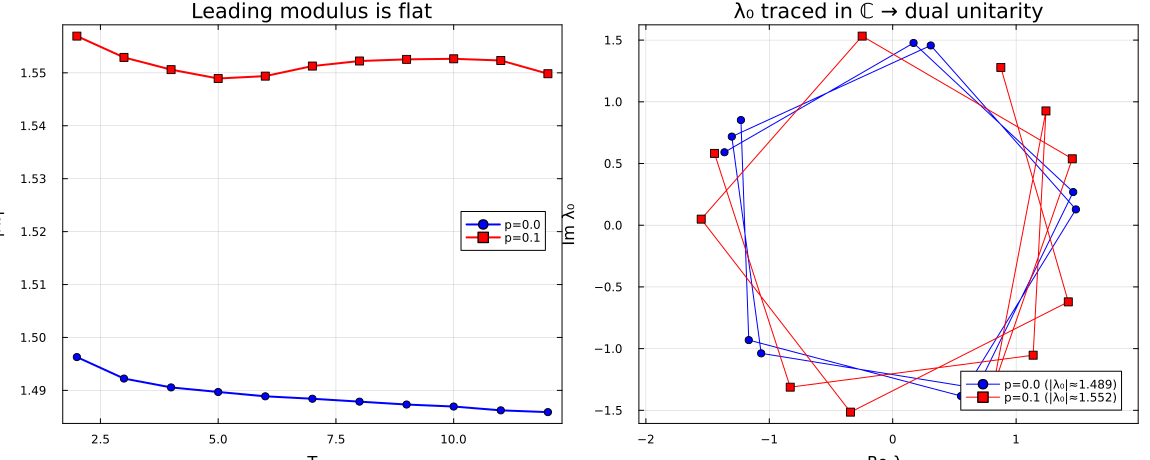

In [7]:
plt = plot(layout=(1, 2), size=(1150, 460))

for (p, color, marker) in [(0.0, :blue, :circle), (0.1, :red, :square)]
    times, eigenvalues = track_lambda0(p)

    modulus_values = abs.(eigenvalues)
    mean_modulus = sum(modulus_values) / length(modulus_values)

    plot!(
        plt,
        times,
        modulus_values;
        subplot=1,
        marker=marker,
        lw=2,
        color=color,
        label="p=$p",
        xlabel="T",
        ylabel="|λ₀|",
        title="Leading modulus is flat",
        framestyle=:box,
        legend=:right,
    )

    plot!(
        plt,
        real.(eigenvalues),
        imag.(eigenvalues);
        subplot=2,
        marker=marker,
        ms=4,
        lw=1,
        color=color,
        label="p=$p (|λ₀|≈$(round(mean_modulus, digits=3)))",
        xlabel="Re λ₀",
        ylabel="Im λ₀",
        title="λ₀ traced in ℂ → dual unitarity",
        framestyle=:box,
        aspect_ratio=:equal,
        legend=:bottomright,
    )
end

mkpath("../results/imgs")
savefig(plt, "../results/imgs/alcaraz_gap_dualunitarity.png")
plt

## But there is still a wall (where the method's reach ends)...

Thanks to the implementation of the block power method AND physical-$\lambda_0$ selection, we are able to reach far past the point where the single-vector power method started to fail in NB3.

Physical-$\lambda_0$ selection (notebook 7's `pick_phys`) is the key trick. At small $T$, the transfer spectrum is still well separated, so the dominant eigenvalue is unambiguous. As $T$ grows and the $-\lambda_0$ partner closes in, we do not simply take the largest modulus (that would randomly grab either member of the near-degenerate pair). Instead we follow, by continuity in the complex plane, the eigenvalue closest to the previous step's $\lambda_0$. This locks onto the true physical branch and skips the partner. Notebook 7 runs this selection along the whole $T$-ladder and stores the result as `theta_phys` in the master cache.

With this, the physical-$\lambda_0$ Rényi-2 dome stays conformal (peak $\sim0.3$, growing logarithmically with $T$) for $p=0.1$ up to $T\approx8$–$9$. However, at $T=10$ it still breaks.

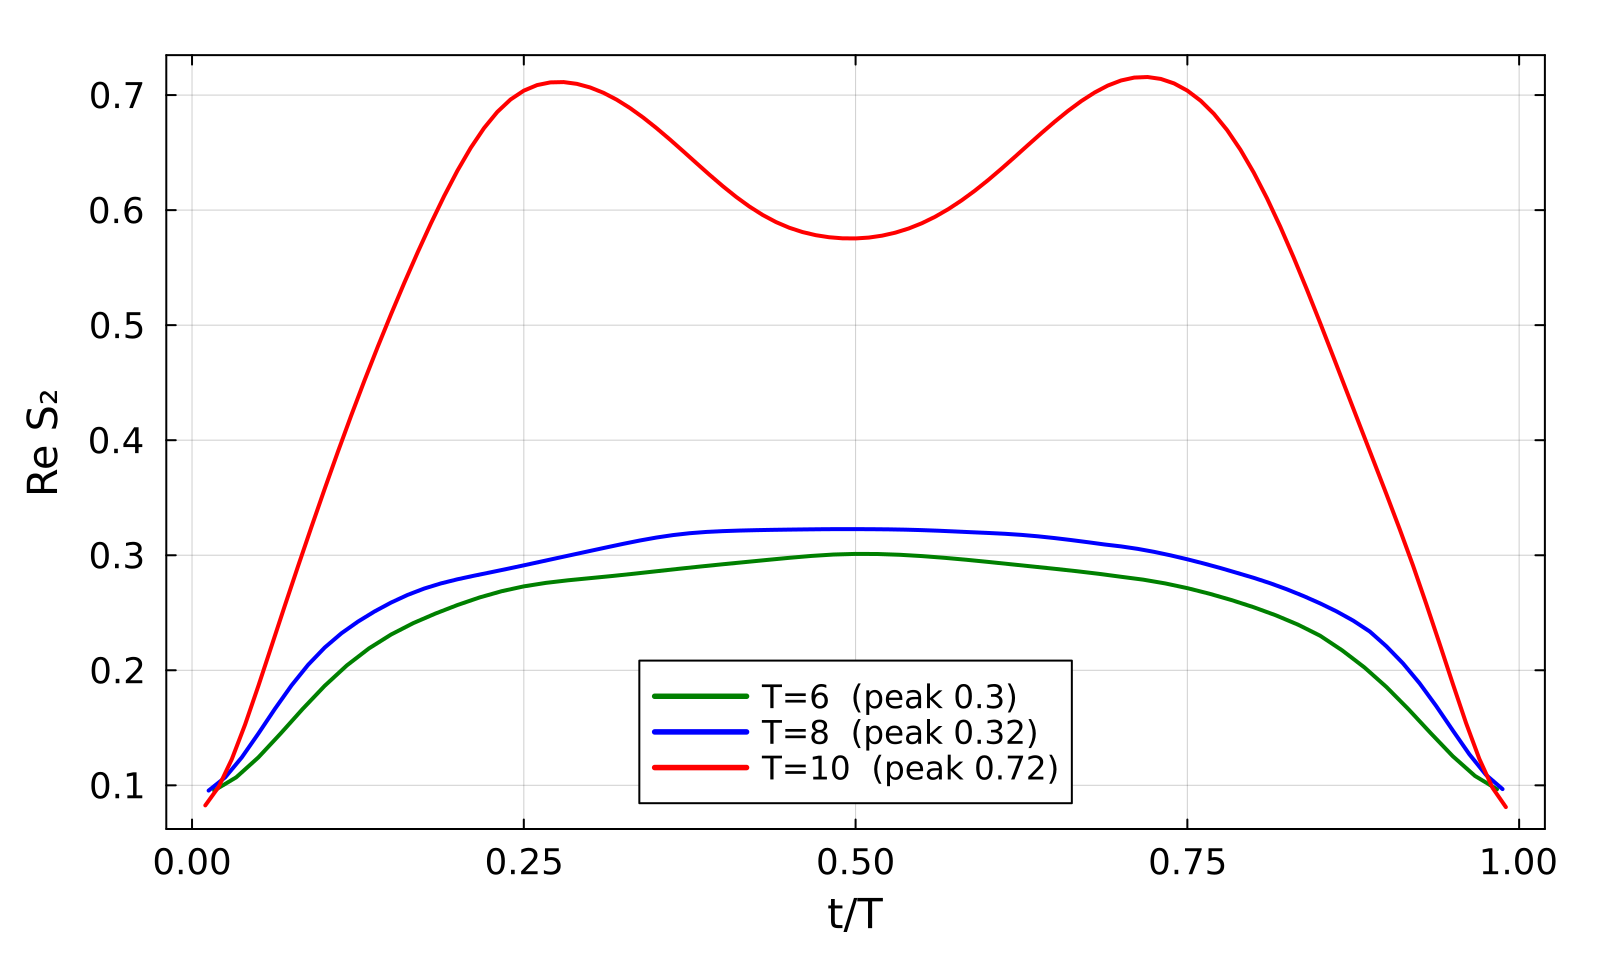

In [8]:
# thesis-quality styling (no in-figure title: the caption does that job)
thesis_plot_theme!()

plt = plot(
        framestyle=:box,
    legend=:bottom,
    xlabel="t/T",
    ylabel="Re S₂",
)

for (temperature, color) in [(6.0, :green), (8.0, :blue), (10.0, :red)]
    haskey(d, (0.1, temperature)) || continue

    entropy_profile = real.(d[(0.1, temperature)].s2_phys)
    normalized_positions = (1:length(entropy_profile)) ./ (length(entropy_profile) + 1)
    peak_value = round(maximum(entropy_profile), digits=2)

    plot!(
        plt,
        normalized_positions,
        entropy_profile;
        color=color,
        lw=2,
        label="T=$(Int(temperature))  (peak $(peak_value))",
    )
end

mkpath("../results/imgs")
savefig(plt, "../results/imgs/gap_closing_wall.png")
plt

## Summary

Putting everything together: the block PM lets us trace the leading transfer spectrum cleanly through the degeneracy, and we see "the entanglement barrier" directly: the gap closes monotonically toward $1$ (faster for the frustrated NNN model), the leading modulus stays flat, and $\lambda_0$ winds on a constant-radius circle. But past $T\approx9-10$ for $p=0.1$, the temporal entropy profiles still break.

Why does the entropy break there while the eigenvalue does not? The eigenVECTOR the entropy needs is ill-conditioned $\sim1/\mathrm{gap}$, while the eigenVALUE stays robust. NB7 investigates how we can still read the central charge past the wall.


---
## Appendix: About DQPTs

At first we thought the closing gap was a non-analytic Loschmidt rate, but here we show why our
quench is not a DQPT. 

The Loschmidt amplitude $\mathcal{L}(t)=\langle\Psi_0|e^{-iHt}|\Psi_0\rangle$ is a boundary partition function with complex "inverse temperature" $it$; its rate function
$\ell(t)=-\tfrac1N\log|\mathcal{L}(t)|^2$ can develop non-analytic kinks at times $t_n^*$ when Fisher zeros cross the time axis (Heyl et al., 2013).

For the transverse-field Ising model, this is exact: a quench from $g_0$ to $g_1$ produces kinks at $t_n^* = (n+\tfrac12)\,\pi/\varepsilon_{k^*}(g_1)$ only if the quench crosses $g_c=1$, where
$\cos k^* = (1+g_0g_1)/(g_0+g_1)$ and $\varepsilon_k(g)=2\sqrt{1+g^2-2g\cos k}$. 

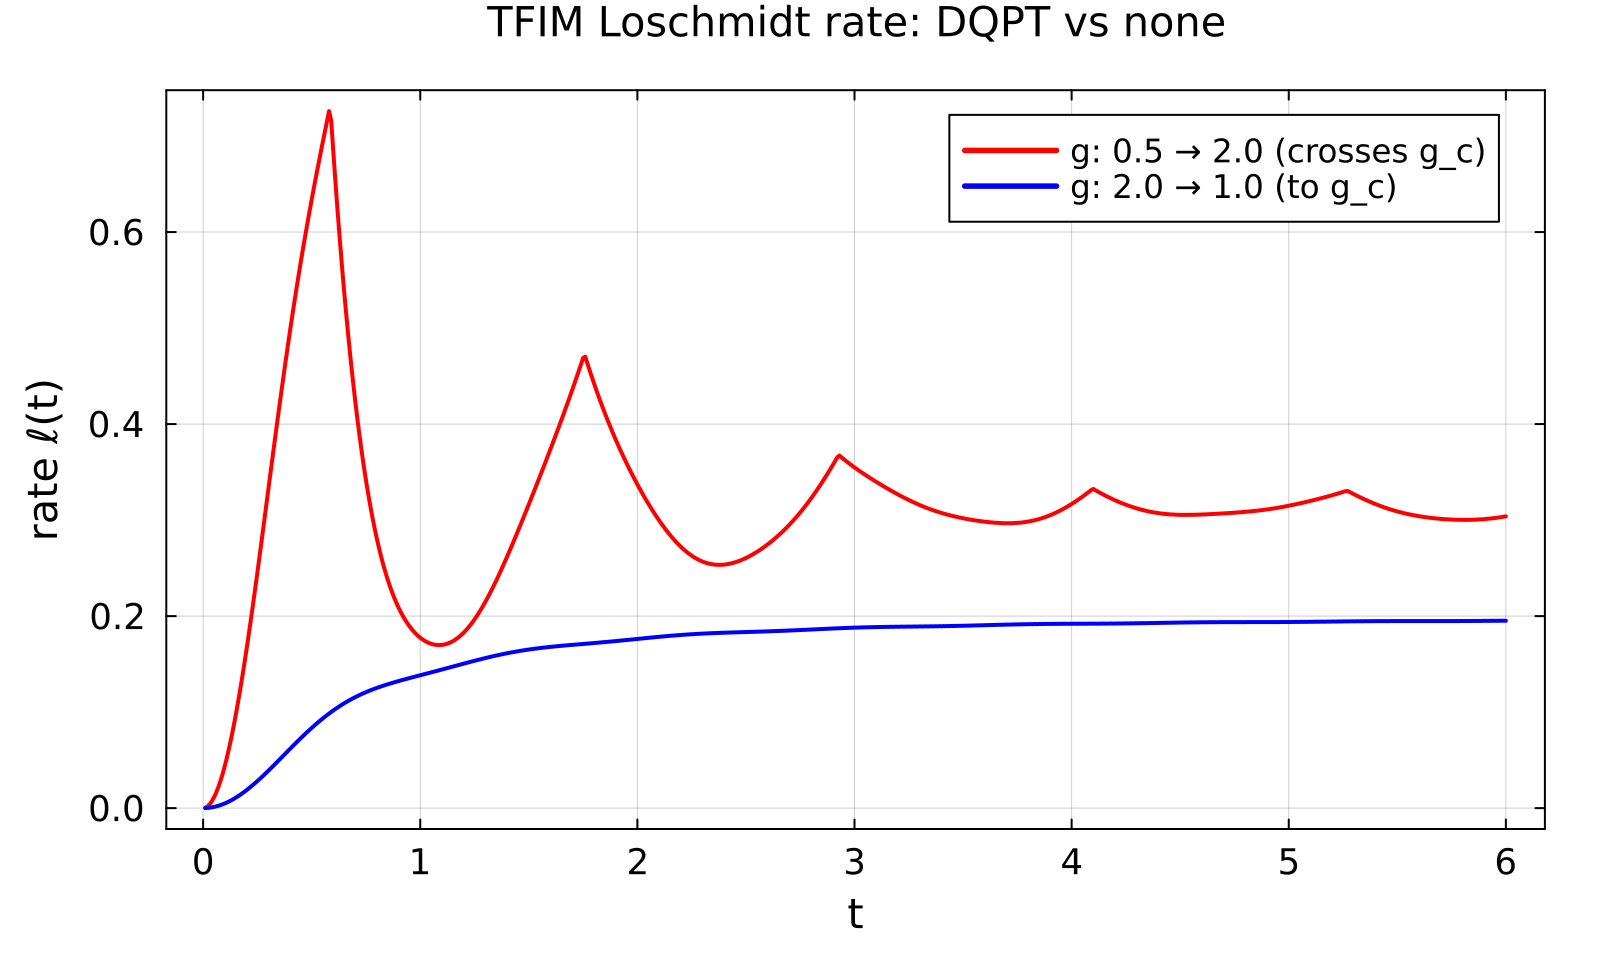

In [9]:
# Exact free-fermion TFIM Loschmidt rate (Heyl et al. 2013)

# Energy of the Bogoliubov quasiparticles
εk(k, g) = 2 * sqrt(1 + g^2 - 2g * cos(k))

# Bogoliubov angle (diagonalizes the Hamiltonian)
θk(k, g) = 0.5 * atan(sin(k), g - cos(k))

function tfim_rate(ts, g0, g1; nk=4000)
    ks = range(0, pi, length=nk)
    dk = step(ks)
    
    # The difference in angles between pre- and post-quench dictates the state overlap.
    overlaps = [sin(2 * (θk(k, g0) - θk(k, g1)))^2 for k in ks]
    energies = [εk(k, g1) for k in ks]
    
    rates = zeros(length(ts))
    
    for (i, t) in enumerate(ts)
        rate_t = 0.0
        for j in eachindex(ks)
            # The mode probability |L_k(t)|^2
            prob = 1.0 - overlaps[j] * sin(energies[j] * t)^2
            
            # The rate diverges when probability vanishes (Fisher zeros crossing the time axis)
            # We enforce a tiny floor to prevent log(0) blow-ups right at the kinks
            prob = max(prob, 1e-300) 
            
            rate_t += -log(prob)
        end
        # Sum over half the Brillouin zone
        rates[i] = (1 / pi) * rate_t * dk
    end
    
    return rates
end

# Run the Quenches
ts = range(0.01, 6.0, length=600)

# Quench ACROSS the critical point (g_c = 1)
cross = tfim_rate(ts, 0.5, 2.0)   
# Quench TO the critical point
tocrit = tfim_rate(ts, 2.0, 1.0) 

# Plotting
plot(ts, cross; 
    label="g: 0.5 → 2.0 (crosses g_c)", 
    lw=2, color=:red, 
    xlabel="t", ylabel="rate ℓ(t)", 
    framestyle=:box, grid=true, 
    title="TFIM Loschmidt rate: DQPT vs none"
)

plot!(ts, tocrit; 
    label="g: 2.0 → 1.0 (to g_c)", 
    lw=2, color=:blue
)

The red curve is the textbook DQPT: sharp kinks for a quench that crosses the critical point. The blue curve corresponds to a quench to the critical point (our case), which is smooth: as $g_1\to g_c=1$, the critical mode moves to $k^*\to0$ where $\varepsilon_{k^*}\to0$ and the first DQPT time $t_1^*\to\infty$. The Fisher zero becomes marginal and never crosses the time axis at finite time.

We always quench the ANNNI-type model to its critical point $\lambda=1$, never across it, so no DQPT occurs at finite time, for $p=0$ or $p>0$. The closing transfer-matrix gap diagnosed above is not a dynamical phase transition.

---
## Appendix: The cost of the block-PM

One iteration of `block_transfer_eigs` costs $2k$ MPO-MPS applications plus $2k$ linear combinations and truncations; the small $k\times k$ pencils are negligible. 

The costs in decreasing order of impact (from the $k=4$ block PM Alcaraz $p=0.1$ sweep):

1. Truncating each matched $(L_j,R_j)$ pair jointly on its bilinear transition matrix (`trunc_mode=:rtm`) converges at $\chi=9$ where the naive per-vector RDM route needs $\chi=44$ for the same $|\lambda_0|$.
2. Warm-starting the $T$-ladder (`pad_tmps`: re-index the converged block onto the longer time-site set, then pad the freshly-added tail randomly) is the biggest iteration-count saver on any sweep.
3. A bond-dimension ramp (`maxdims=2:2:cap`) and a looser-early cutoff schedule cost nothing in eigenvalue accuracy and trim the early iterations.
4. Kernel choice is a physics decision, not a cost one. WII has a smaller temporal physical dimension per apply (cheaper) but is genuinely 1st-order for NNN models (only 2nd order for strictly NN models such as the XXZ one in NBs 8-9). VD2 for Alcaraz is our standard.
5. Block size: $k=2$ for eigenvalue-only sweeps, $k=4$ for entropy work, $k=6$ only to resolve a symmetry band.